# King County Housing — Exploratory Data Analysis

**Analyst:** Keitha · **Client:** Charles Christensen (Seller / investor)

> *"Invest with big returns. Wondering about renovation? Which neighborhood? Timing?"*

Charles is the least-specified client on the list, so the first job is to pin down what his
question actually means. Everything below flows from the assumptions in the next cell.

---

## What this notebook does

| Section | Question |
|---|---|
| 1–4 | What is in this data, and what has to be fixed before I can trust it? |
| 5 | What exactly am I asking? |
| 6 | What does the data look like on its own? |
| 7 | **Where** should Charles buy? |
| 8 | **What** should he change about a house? |
| 9 | **When** should he buy and sell? |
| 10 | What did people who actually did this **earn**? |
| 11–12 | Insights and recommendations |
| 13 | Presentation-quality charts for the slide deck |

## Assumptions

The assignment says: *"Whatever assumptions you make, please write them explicitly."* Here they are.

1. **"Investor" means buy → improve → resell.** Charles is listed as a Seller, but "invest with
   big returns" only makes sense as a round trip, so both sides of the trade are analysed.
2. **"Big returns" = gain on resale relative to purchase price, gross.** This data has no
   renovation costs, agent fees or carrying costs, so nothing here is a *net* return.
3. **"Neighborhood" = zipcode.** It is the only neighborhood unit in the dataset.
4. **`price_per_sqft = price / sqft_living`** is used throughout, so houses of different sizes
   can be compared fairly.
5. **A zipcode is "investable"** if it had at least 150 sales in the year — enough activity that
   Charles can actually sell again inside his horizon.
6. **`yr_renovated` missing = not renovated.** 3,848 rows are affected. Every result below was
   re-run dropping those rows instead, and nothing moved materially.

---

# 1. Setup

## Installing what we need

This notebook needs two packages that are **not** in the project's `pyproject.toml`:

- **`statsmodels`** — used once in section 8, to compare several price drivers at the same time.
- **`kaleido`** — used in section 13, to save the Plotly charts as PNG files for your slides.

Run this **once** in your terminal, in the project folder:

```bash
uv add statsmodels kaleido
```

That updates `pyproject.toml` and `uv.lock` and installs both into your `.venv`. Commit both files —
your teammates then run `uv sync` and get the same environment.

> **If section 13 later says "Kaleido requires Google Chrome":** saving a chart as an image works by
> rendering it in a browser behind the scenes. Run `uv run plotly_get_chrome` once and it will fetch
> a copy for itself. This does not touch the Chrome you browse with.

In [1]:
# --- Standard data tools ---
import numpy as np                  # maths on arrays of numbers
import pandas as pd                 # tables (the "DataFrame")

# --- Plotting ---
import matplotlib.pyplot as plt     # quick exploration charts
import seaborn as sns               # prettier statistical charts, built on matplotlib
import missingno as msno            # a picture of where data is missing

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Reset plotting styles (important for PyCharm Jupyter)
plt.style.use("default")
mpl.rcdefaults()
sns.reset_defaults()

# --- Display settings ---
pd.set_option("display.max_columns", 50)   # show all columns, don't truncate
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")   # 1234.5 -> 1,234.50

# House style for the exploration charts in sections 6-10.
# The polished presentation charts come later, in section 13.
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,        # remove the box around the plot
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# One colour used consistently for exploration charts, and one accent
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#898781"

# Make text visible
mpl.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "font.size": 12
})

print("Setup complete.")

Setup complete.


---

# 2. Load the data and take a first look

The data came from the bootcamp PostgreSQL database. Two tables in the `eda` schema were joined —
one holding **sales** (date, price) and one holding **house features** (size, grade, location) —
and saved to `data/eda.csv` by notebook `03_fetching_the_data_eda.ipynb`.

The join used:

```sql
SELECT sales.date, sales.price, details.*
FROM eda.king_county_house_sales AS sales
JOIN eda.king_county_house_details AS details
  ON sales.house_id = details.id
```

> **Why a CSV and not a live query?** Re-running the query every time is slow, and if the database
> goes down mid-project your analysis stops. The CSV is a local snapshot. It stays out of GitHub
> because the `data/` folder is in `.gitignore`.

In [2]:
df = pd.read_csv("data/eda.csv")

print("Rows (sales):", len(df))
print("Columns:", df.shape[1])
df.head()

Rows (sales): 21597
Columns: 21


,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,"221,900.00",7129300520,3.00,1.00,"1,180.00","5,650.00",1.00,NaN,0.00,3,7,"1,180.00",0.00,1955,0.00,98178,47.51,-122.26,"1,340.00","5,650.00"
1,2014-12-09,"538,000.00",6414100192,3.00,2.25,"2,570.00","7,242.00",2.00,0.00,0.00,3,7,"2,170.00",400.00,1951,"19,910.00",98125,47.72,-122.32,"1,690.00","7,639.00"
2,2015-02-25,"180,000.00",5631500400,2.00,1.00,770.00,"10,000.00",1.00,0.00,0.00,3,6,770.00,0.00,1933,NaN,98028,47.74,-122.23,"2,720.00","8,062.00"
3,2014-12-09,"604,000.00",2487200875,4.00,3.00,"1,960.00","5,000.00",1.00,0.00,0.00,5,7,"1,050.00",910.00,1965,0.00,98136,47.52,-122.39,"1,360.00","5,000.00"
4,2015-02-18,"510,000.00",1954400510,3.00,2.00,"1,680.00","8,080.00",1.00,0.00,0.00,3,8,"1,680.00",0.00,1987,0.00,98074,47.62,-122.05,"1,800.00","7,503.00"


`.head()` shows the first five rows. Always look at this before anything else — it catches
"the file loaded wrong" mistakes immediately.

In [3]:
# What type is each column, and how much memory does this use?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21597 non-null  str    
 1   price          21597 non-null  float64
 2   id             21597 non-null  int64  
 3   bedrooms       21597 non-null  float64
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  float64
 6   sqft_lot       21597 non-null  float64
 7   floors         21597 non-null  float64
 8   waterfront     19206 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  float64
 13  sqft_basement  21145 non-null  float64
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17749 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long           21

In [4]:
# Descriptive statistics for every numeric column:
# count, mean, standard deviation, min, the quartiles, and max.
df.describe()

,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,597.00","21,597.00","21,597.00","21,597.00","21,597.00","21,597.00","21,597.00","19,206.00","21,534.00","21,597.00","21,597.00","21,597.00","21,145.00","21,597.00","17,749.00","21,597.00","21,597.00","21,597.00","21,597.00","21,597.00"
mean,"540,296.57","4,580,474,287.77",3.37,2.12,"2,080.32","15,099.41",1.49,0.01,0.23,3.41,7.66,"1,788.60",291.86,"1,971.00",836.65,"98,077.95",47.56,-122.21,"1,986.62","12,758.28"
std,"367,368.14","2,876,735,715.75",0.93,0.77,918.11,"41,412.64",0.54,0.09,0.77,0.65,1.17,827.76,442.49,29.38,"4,000.11",53.51,0.14,0.14,685.23,"27,274.44"
min,"78,000.00","1,000,102.00",1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"322,000.00","2,123,049,175.00",3.00,1.75,"1,430.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"450,000.00","3,904,930,410.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"645,000.00","7,308,900,490.00",4.00,2.50,"2,550.00","10,685.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"7,700,000.00","9,900,000,190.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","20,150.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


### What to look for in `.describe()`

Read across each row and ask *"is that physically possible?"*

- **`price`** runs from \$78,000 to \$7,700,000. Plausible for Seattle.
- **`bedrooms`** has a max of **33**. A 33-bedroom house? Look at it — it is a 1,620 sqft house.
  That is a famous typo in this dataset (almost certainly 3). We will drop it.
- **`yr_renovated`** has a max around **20,150**. That is not a year. We will come back to this —
  it is the single most dangerous thing in this file.
- **`sqft_basement`** has a lower `count` than the other columns, which means missing values.

In [5]:
# Look at the suspicious row directly, rather than assuming
df[df["bedrooms"] > 10][["price", "bedrooms", "bathrooms", "sqft_living", "yr_built", "zipcode"]]

,price,bedrooms,bathrooms,sqft_living,yr_built,zipcode
8748,"520,000.00",11.00,3.00,"3,000.00",1918,98106
15856,"640,000.00",33.00,1.75,"1,620.00",1947,98103


---

# 3. Missing values

Two questions matter: **how many** values are missing, and **are they concentrated** in particular
columns or particular rows? A column that is 20% empty is a different problem from a handful of
rows that are empty everywhere.

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

summary = pd.DataFrame({
    "missing": missing,
    "percent": (missing / len(df) * 100).round(1),
})
summary

,missing,percent
yr_renovated,3848,17.80
waterfront,2391,11.10
sqft_basement,452,2.10
view,63,0.30


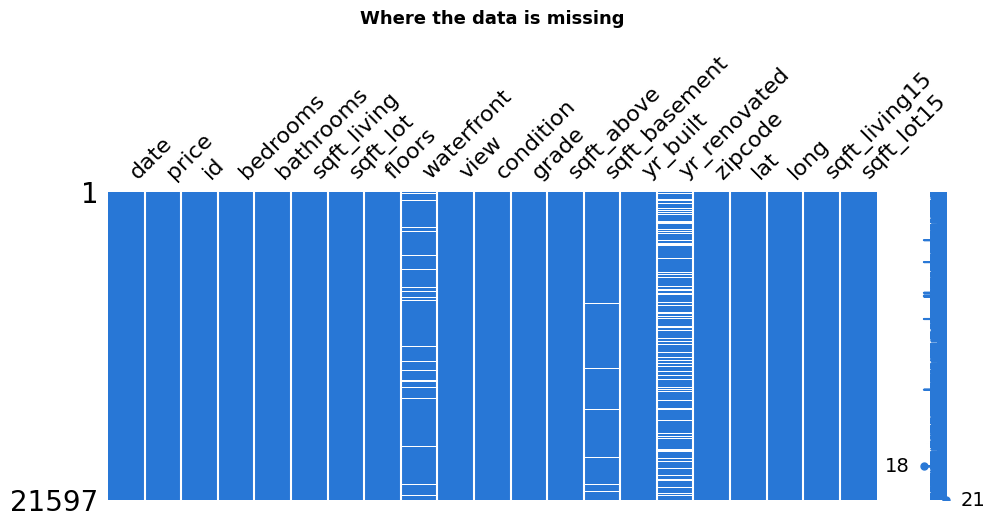

In [7]:
# A visual version: each column is a vertical bar, white gaps are missing values.
msno.matrix(df, color=(0.16, 0.47, 0.84), figsize=(11, 4))
plt.title("Where the data is missing", pad=20)
plt.show()

**What this shows:** the gaps are spread evenly down the file rather than clustered in a block.
So this is not "the last 2,000 rows failed to load" — it is genuinely unrecorded information,
scattered at random. That means we can fix the columns one at a time instead of dropping rows.

---

# 4. Cleaning

Four fixes. Each one gets a reason, because an unexplained cleaning decision is what makes an
analysis untrustworthy — *"garbage in, garbage out"* applies to conclusions, not just models.

### Fix 1 — `yr_renovated` is stored multiplied by 10 ⚠️

This is the dangerous one. The values arrive as `19910`, `20140`, `19340`. Nothing errors. Python
happily treats them as numbers. But every renovation result you compute will be wrong, and
nothing will warn you.

### Fix 2 — `sqft_basement` can be reconstructed, not guessed

A house's living space is what is above ground plus what is below:

$$\text{sqft\_living} = \text{sqft\_above} + \text{sqft\_basement}$$

So the missing basement values can be *calculated* rather than filled with a guess. We check the
identity holds before relying on it.

### Fix 3 — `waterfront` and `view` missing → 0

`waterfront` is missing for ~2,400 rows. Only 146 houses in the entire dataset are waterfront, so
whichever way we treat the missing ones barely moves any average. Filling with 0 ("not waterfront")
is the defensible choice — but we state it rather than doing it silently.

### Fix 4 — drop the 33-bedroom typo

One row. A known data-entry error.

In [8]:
# Work on a copy so the raw load stays untouched and we can always compare back
df_raw = df.copy()

# --- Fix 1: yr_renovated stored x10 -------------------------------------
print("BEFORE — non-zero yr_renovated values look like:",
      df.loc[df["yr_renovated"] > 0, "yr_renovated"].head(3).tolist())

df["yr_renovated"] = df["yr_renovated"] / 10

print("AFTER  — the same values now read:",
      df.loc[df["yr_renovated"] > 0, "yr_renovated"].head(3).tolist())
print("Range of renovation years:",
      df.loc[df["yr_renovated"] > 0, "yr_renovated"].min(), "to",
      df.loc[df["yr_renovated"] > 0, "yr_renovated"].max())

BEFORE — non-zero yr_renovated values look like: [19910.0, 20020.0, 19910.0]
AFTER  — the same values now read: [1991.0, 2002.0, 1991.0]
Range of renovation years: 1934.0 to 2015.0


In [9]:
# --- Fix 2: reconstruct sqft_basement -----------------------------------
# First PROVE the identity holds on the rows where nothing is missing.
complete = df[df["sqft_basement"].notna()]
error = (complete["sqft_living"] - complete["sqft_above"] - complete["sqft_basement"]).abs().max()
print(f"Largest error in sqft_living = sqft_above + sqft_basement: {error}")
print(f"(checked on {len(complete):,} complete rows)")

# It holds exactly, so we can rebuild the missing values instead of guessing.
df["sqft_basement"] = df["sqft_basement"].fillna(df["sqft_living"] - df["sqft_above"])
print("Missing sqft_basement after the fix:", df["sqft_basement"].isna().sum())

Largest error in sqft_living = sqft_above + sqft_basement: 0.0
(checked on 21,145 complete rows)
Missing sqft_basement after the fix: 0


In [10]:
# --- Fix 3: waterfront / view missing -> 0 ------------------------------
print("Waterfront houses in the data:", int(df["waterfront"].sum()), "out of", len(df))
df["waterfront"] = df["waterfront"].fillna(0)
df["view"] = df["view"].fillna(0)

# --- Fix 4: drop the 33-bedroom typo ------------------------------------
before = len(df)
df = df[df["bedrooms"] < 33].copy()
print(f"Dropped {before - len(df)} row (the 33-bedroom typo). {len(df):,} sales remain.")

print("\nRemaining missing values:")
print(df.isnull().sum()[lambda s: s > 0])

Waterfront houses in the data: 146 out of 21597
Dropped 1 row (the 33-bedroom typo). 21,596 sales remain.

Remaining missing values:
yr_renovated    3848
dtype: int64


**How much data did we throw away?** One row out of 21,597 — **0.005%**. Everything else was
repaired rather than deleted. That is the ideal outcome: we lost almost nothing, and we can say
exactly what we did to each column.

`yr_renovated` still has 3,848 missing values. Those are genuinely unknown, and section 8 treats
them as "not renovated" — a choice we test later.

---

## 4b. New columns

Some questions cannot be asked of the raw columns. A few derived ones make the rest of the
notebook possible.

| New column | What it is | Why we need it |
|---|---|---|
| `price_per_sqft` | price ÷ living area | Compares a small house to a big one fairly |
| `sale_month` | month number of the sale | Answers the timing question |
| `house_age` | sale year − year built | Age matters more than the build year itself |
| `renovated` | 1 if ever renovated, else 0 | A simple yes/no flag to compare groups |

In [11]:
df["date"] = pd.to_datetime(df["date"])       # text -> real dates, so we can extract months

df["price_per_sqft"] = df["price"] / df["sqft_living"]
df["sale_month"]     = df["date"].dt.month
df["sale_ym"]        = df["date"].dt.to_period("M")     # e.g. 2014-10, for a real timeline
df["house_age"]      = df["date"].dt.year - df["yr_built"]
df["renovated"]      = (df["yr_renovated"].fillna(0) > 0).astype(int)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Distinct houses:", df["id"].nunique(), "| Sales:", len(df))
print("Zipcodes:", df["zipcode"].nunique())
df[["price", "price_per_sqft", "sale_month", "house_age", "renovated"]].head()

Date range: 2014-05-02 to 2015-05-27
Distinct houses: 21419 | Sales: 21596
Zipcodes: 70


,price,price_per_sqft,sale_month,house_age,renovated
0,"221,900.00",188.05,10,59,0
1,"538,000.00",209.34,12,63,1
2,"180,000.00",233.77,2,82,0
3,"604,000.00",308.16,12,49,0
4,"510,000.00",303.57,2,28,0


> **Notice:** 21,596 sales but only 21,419 distinct houses. Some houses sold **twice** inside this
> one-year window. Hold that thought — section 10 turns it into the most interesting finding in
> the whole project.

---

# 5. Research questions and hypotheses

This is the step it is tempting to skip, and skipping it is why EDA notebooks turn into 80 random
charts with no story. Writing the questions down **first** means every chart below exists to
answer something.

- A **research question** is open: *"Does location affect price?"*
- A **hypothesis** is a testable guess, in `if/then` or `the more … the more` form:
  *"If a house is on the waterfront, then it sells for more."*

Three questions, taken straight from what Charles asked, plus a fourth that the data made possible.

| # | Question (Charles's words) | Hypotheses | Columns used |
|---|---|---|---|
| **Q1** | *"Which neighborhood?"* | H1a. The more expensive the zipcode, the higher the price per sqft.<br>H1b. Price varies more **between** zipcodes than within any one of them. | `zipcode`, `lat`, `long`, `price_per_sqft` |
| **Q2** | *"Wondering about renovation?"* | H2a. The bigger the house, the higher the price.<br>H2b. If a house is renovated, then it sells for more.<br>H2c. Build quality (`grade`) matters more than upkeep (`condition`). | `sqft_living`, `grade`, `condition`, `renovated` |
| **Q3** | *"Timing?"* | H3a. Houses sold in spring fetch more per sqft than houses sold in winter. | `sale_month`, `price_per_sqft` |
| **Q4** | *"Invest with big returns"* | H4a. Houses that sold twice in this window made a profit.<br>H4b. The bigger the discount at purchase, the bigger the eventual gain. | `id`, `date`, `price` |

> **A note on H2b.** It looks obviously true. Section 8 shows it is the most misleading result in
> the entire dataset, and catching *why* is the most valuable thing in this notebook.

---

# 6. Distributions — what does the data look like on its own?

Before comparing anything to anything, look at each variable by itself. Histograms answer:
where is the data centred, is it lopsided, are there extreme values, are there hidden groups?

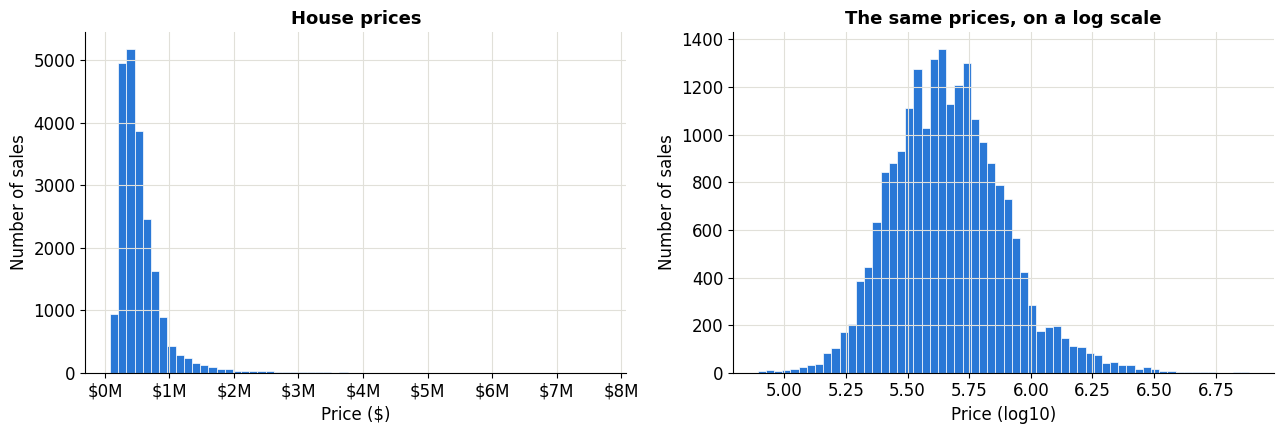

count      21,596.00
mean      540,291.96
std       367,376.02
min        78,000.00
25%       322,000.00
50%       450,000.00
75%       645,000.00
max     7,700,000.00
Name: price, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["price"], bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("House prices")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Number of sales")
axes[0].xaxis.set_major_formatter(lambda x, p: f"${x/1e6:.0f}M")

# The same data on a log scale. A log scale squashes the huge values so the
# shape of the bulk becomes visible.
axes[1].hist(np.log10(df["price"]), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].set_title("The same prices, on a log scale")
axes[1].set_xlabel("Price (log10)")
axes[1].set_ylabel("Number of sales")

plt.tight_layout()
plt.show()

print(df["price"].describe())

**What this shows.** The left chart is **right-skewed** (a long tail to the right): most houses sell
between \$300k and \$650k, and a thin tail of luxury homes stretches to \$7.7M. The mean (\$540k) is
pulled well above the median (\$450k) by that tail.

**Consequence for the rest of the notebook:** we use the **median**, not the mean, whenever we
summarise prices. One \$7.7M sale would drag a mean around; it barely moves a median.

The right chart shows that on a log scale the distribution is close to a neat bell curve. That is
why section 8's model works on `log(price)` rather than raw price.

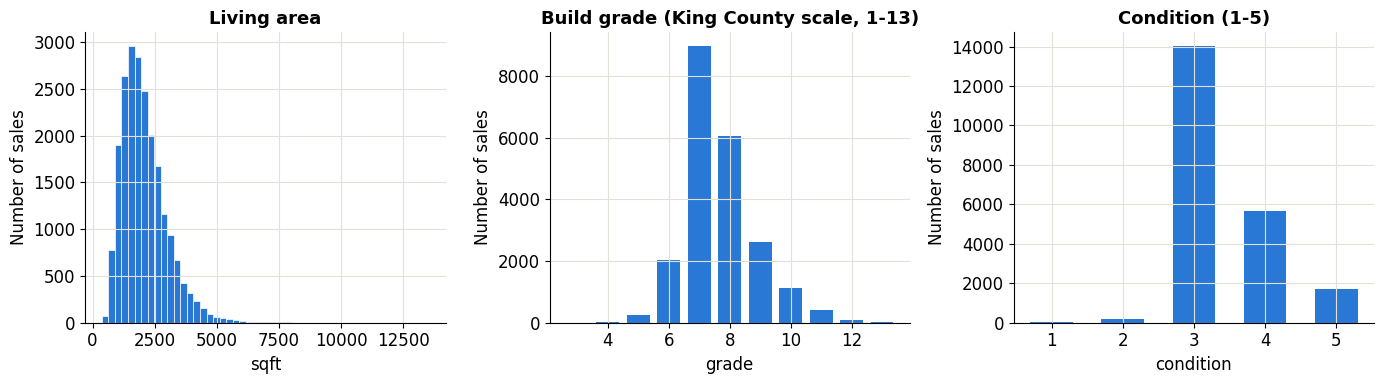

Share of sales at each grade (%):
grade
3     0.00
4     0.10
5     1.10
6     9.40
7    41.50
8    28.10
9    12.10
10    5.30
11    1.80
12    0.40
13    0.10
Name: proportion, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["sqft_living"], bins=50, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("Living area")
axes[0].set_xlabel("sqft")

grade_counts = df["grade"].value_counts().sort_index()
axes[1].bar(grade_counts.index, grade_counts.values, color=BLUE, width=0.75)
axes[1].set_title("Build grade (King County scale, 1-13)")
axes[1].set_xlabel("grade")

cond_counts = df["condition"].value_counts().sort_index()
axes[2].bar(cond_counts.index, cond_counts.values, color=BLUE, width=0.6)
axes[2].set_title("Condition (1-5)")
axes[2].set_xlabel("condition")

for ax in axes:
    ax.set_ylabel("Number of sales")
plt.tight_layout()
plt.show()

print("Share of sales at each grade (%):")
print((df["grade"].value_counts(normalize=True).sort_index() * 100).round(1))

**What this shows — and why it matters to Charles.**

`grade` is King County's rating of **construction quality and materials** (1–13, where 7 is the
county's "average"). `condition` is a different thing: how well the house has been **kept up** (1–5).

The grade chart is the important one. **41.5% of all sales are grade 7** and another 9.4% are
grade 6. In other words, half the market sits at or just below average build quality. If build
quality turns out to be worth money (section 8 tests this), then there is a very large supply of
houses with room to improve.

---

# 7. Q1 — Where? The geographical insight

> **H1a.** The more expensive the zipcode, the higher the price per sqft.
> **H1b.** Price varies more between zipcodes than within any one of them.

The dataset has three location columns: `zipcode`, `lat` (latitude) and `long` (longitude).
Latitude and longitude are just coordinates — if we scatter them against each other, we literally
draw the map of King County.

In [14]:
zip_stats = df.groupby("zipcode").agg(
    sales=("price", "size"),
    med_price=("price", "median"),
    med_ppsf=("price_per_sqft", "median"),
).sort_values("med_ppsf", ascending=False)

print("Most expensive zipcodes by price per sqft:")
display(zip_stats.head(5))
print("Least expensive:")
display(zip_stats.tail(5))

print(f"\nSpread in price per sqft: ${zip_stats['med_ppsf'].min():,.0f} "
      f"({zip_stats['med_ppsf'].idxmin()}) to ${zip_stats['med_ppsf'].max():,.0f} "
      f"({zip_stats['med_ppsf'].idxmax()})")
print(f"  ratio: {zip_stats['med_ppsf'].max() / zip_stats['med_ppsf'].min():.1f}x")
print(f"\nSpread in total price: ${zip_stats['med_price'].min():,.0f} to "
      f"${zip_stats['med_price'].max():,.0f}")
print(f"  ratio: {zip_stats['med_price'].max() / zip_stats['med_price'].min():.1f}x")

Most expensive zipcodes by price per sqft:


,sales,med_price,med_ppsf
zipcode,,,
98039,50,"1,895,000.00",565.17
98004,317,"1,150,000.00",456.94
98109,109,"736,000.00",427.70
98112,269,"915,000.00",424.24
98119,184,"744,975.00",416.65


Least expensive:


,sales,med_price,med_ppsf
zipcode,,,
98092,351,"309,780.00",149.18
98002,199,"235,000.00",147.18
98001,361,"260,000.00",147.14
98032,125,"249,000.00",146.21
98023,499,"268,450.00",144.97



Spread in price per sqft: $145 (98023) to $565 (98039)
  ratio: 3.9x

Spread in total price: $235,000 to $1,895,000
  ratio: 8.1x


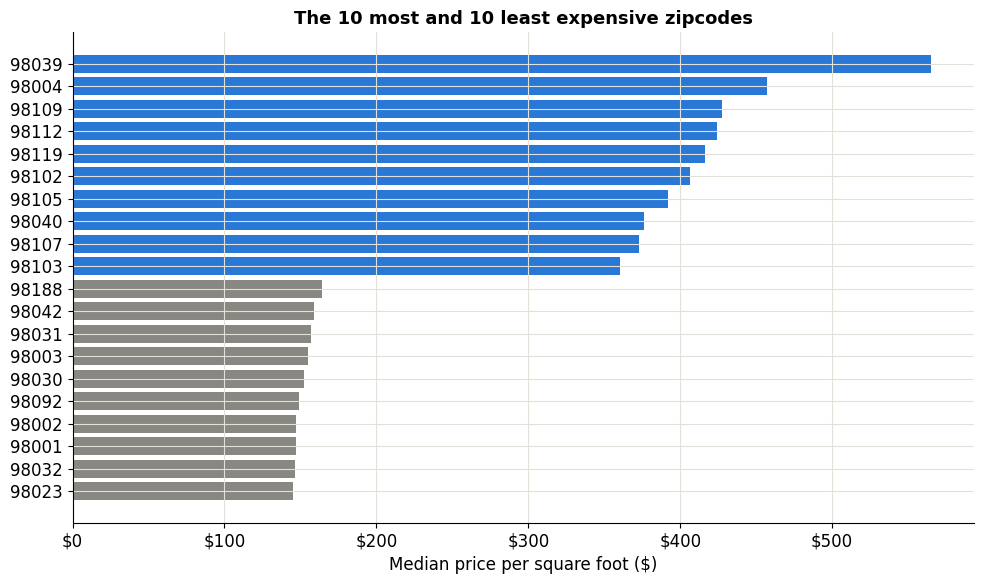

In [15]:
# Top and bottom 10 zipcodes side by side
top10 = zip_stats.head(10)
bot10 = zip_stats.tail(10).sort_values("med_ppsf", ascending=False)
combined = pd.concat([top10, bot10])
colors = [BLUE] * 10 + [GREY] * 10

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([str(z) for z in combined.index], combined["med_ppsf"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Median price per square foot ($)")
ax.set_title("The 10 most and 10 least expensive zipcodes")
ax.xaxis.set_major_formatter(lambda x, p: f"${x:.0f}")
plt.tight_layout()
plt.show()

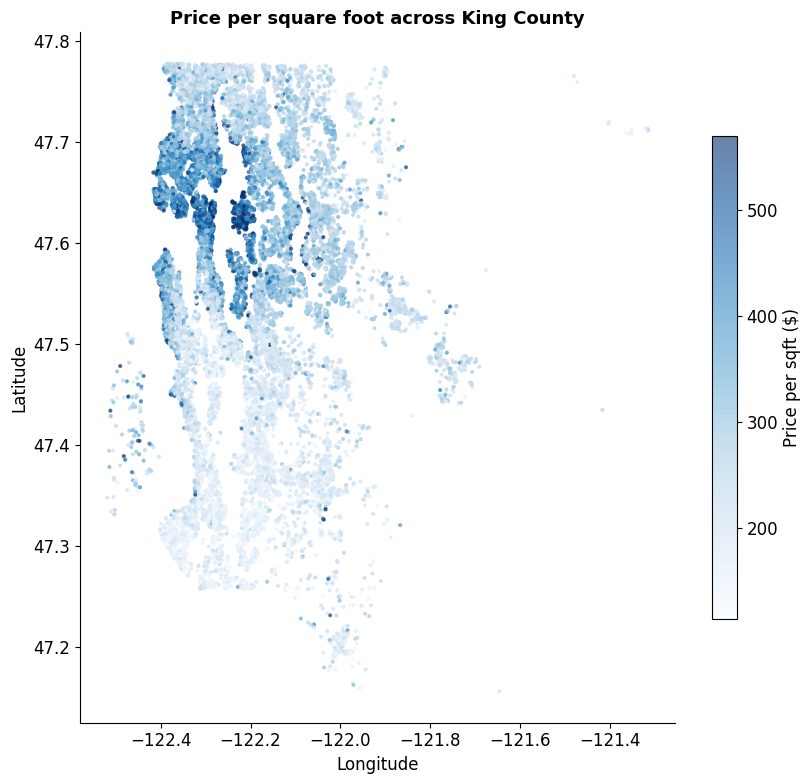

In [16]:
# lat/long scatter = a real map of King County, coloured by price per sqft
fig, ax = plt.subplots(figsize=(8.5, 8))
sc = ax.scatter(df["long"], df["lat"], c=df["price_per_sqft"],
                cmap="Blues", s=4, alpha=0.6,
                vmin=df["price_per_sqft"].quantile(0.02),
                vmax=df["price_per_sqft"].quantile(0.98))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Price per square foot across King County")
ax.grid(False)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Price per sqft ($)")
plt.tight_layout()
plt.show()

### ✅ H1a and H1b both hold — this is Insight 1

**Median price per square foot runs from \$145 in 98023 (Federal Way) to \$565 in 98039 (Medina) —
a 3.9× spread.** On total price the gap is **8×**: \$235,000 in 98002 against \$1,895,000 in 98039.

The map shows the pattern clearly: a dark, expensive core around Seattle and the Bellevue/Medina
shoreline of Lake Washington, fading south and east.

**The same house, moved across the county, changes price by a factor of four.** No other variable
in this dataset comes close. For Charles, location is not one factor among many — it is the frame
every other decision sits inside.

---

# 8. Q2 — What? The drivers of price

> **H2a.** The bigger the house, the higher the price.
> **H2b.** If a house is renovated, then it sells for more.
> **H2c.** Build quality (`grade`) matters more than upkeep (`condition`).

## 8.1 Correlation — which columns move with price?

A **correlation** measures how strongly two columns move together, from −1 to +1. 0 means no
straight-line relationship; 1 means perfect lockstep. It only detects *straight-line* relationships,
and it never proves that one thing causes the other — but it is a fast way to see what deserves a
closer look.

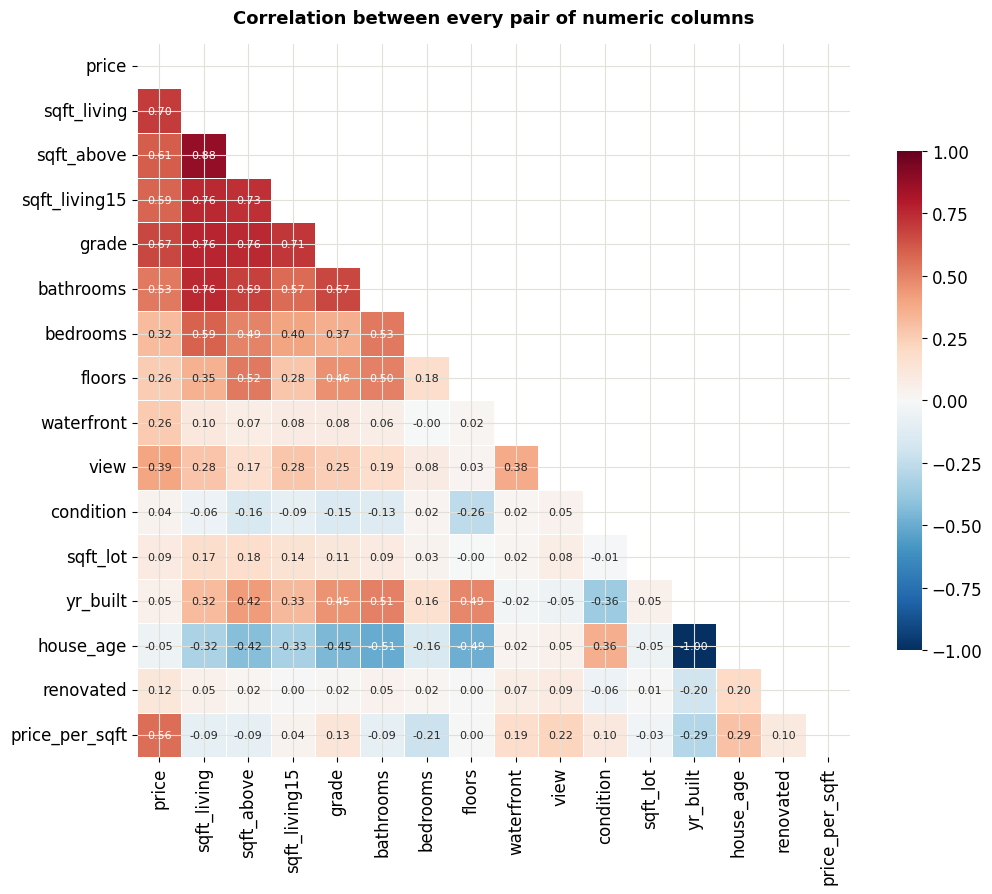

In [17]:
numeric = ["price", "sqft_living", "sqft_above", "sqft_living15", "grade", "bathrooms",
           "bedrooms", "floors", "waterfront", "view", "condition", "sqft_lot",
           "yr_built", "house_age", "renovated", "price_per_sqft"]

corr = df[numeric].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))    # hide the mirrored upper half
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation between every pair of numeric columns", pad=15)
plt.tight_layout()
plt.show()

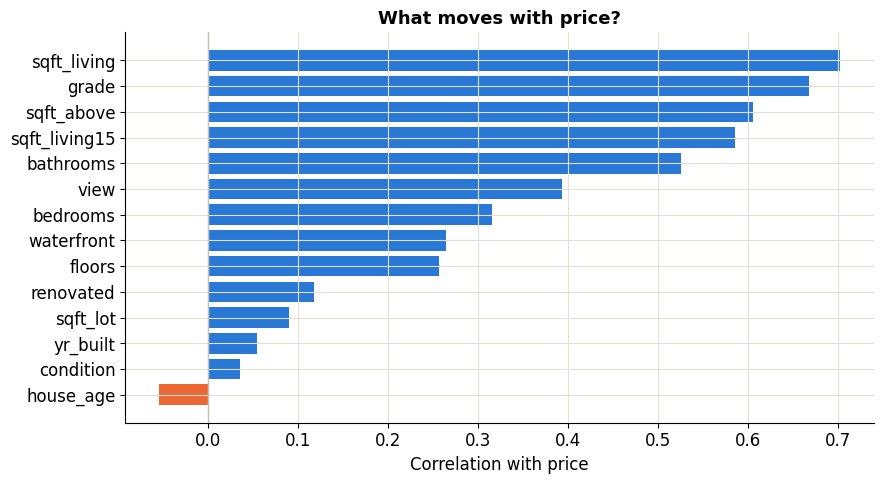

sqft_living      0.70
grade            0.67
sqft_above       0.60
sqft_living15    0.58
bathrooms        0.53
view             0.39
bedrooms         0.32
waterfront       0.26
floors           0.26
renovated        0.12
sqft_lot         0.09
yr_built         0.05
condition        0.04
house_age       -0.05
Name: price, dtype: float64

In [18]:
# Just the column we care about, sorted
price_corr = corr["price"].drop(["price", "price_per_sqft"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [BLUE if v > 0 else ORANGE for v in price_corr.values]
ax.barh(price_corr.index, price_corr.values, color=colors)
ax.invert_yaxis()
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("Correlation with price")
ax.set_title("What moves with price?")
plt.tight_layout()
plt.show()

price_corr.round(3)

**What this shows.** `sqft_living` (0.70) and `grade` (0.67) lead by a wide margin. `renovated`
manages only **0.12**, and `condition` is essentially **0.04** — near zero.

That is already surprising: the thing Charles is *asking* about (renovation) barely registers,
and condition, which sounds like it should matter, does not move with price at all.

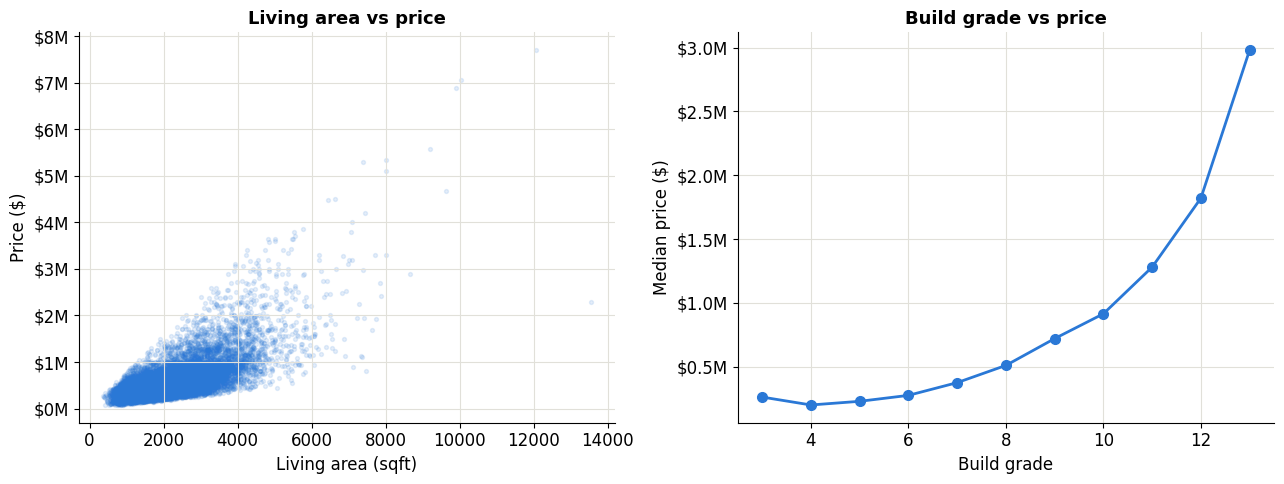

In [19]:
# H2a: bigger = more expensive?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["sqft_living"], df["price"], alpha=0.12, s=8, color=BLUE)
axes[0].set_xlabel("Living area (sqft)")
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Living area vs price")
axes[0].yaxis.set_major_formatter(lambda x, p: f"${x/1e6:.0f}M")

# Median price for each grade makes the grade relationship much clearer than a scatter
grade_price = df.groupby("grade")["price"].median()
axes[1].plot(grade_price.index, grade_price.values, marker="o",
             color=BLUE, linewidth=2, markersize=7)
axes[1].set_xlabel("Build grade")
axes[1].set_ylabel("Median price ($)")
axes[1].set_title("Build grade vs price")
axes[1].yaxis.set_major_formatter(lambda x, p: f"${x/1e6:.1f}M")

plt.tight_layout()
plt.show()

✅ **H2a holds.** Bigger houses cost more — the cloud clearly slopes upward. Note it also *fans
out*: at 2,000 sqft prices range from about \$200k to \$2M, which is another way of seeing that
size alone does not determine price.

✅ **H2c holds so far.** Each grade step lifts the median price, and the curve steepens at the top.

## 8.2 ⚠️ The renovation trap — the most important cell in this notebook

Now test **H2b**: *if a house is renovated, then it sells for more.*

The obvious way is to compare the two groups directly. Watch what happens.

In [20]:
naive = df.groupby("renovated").agg(
    houses=("price", "size"),
    median_price=("price", "median"),
    median_sqft=("sqft_living", "median"),
    median_grade=("grade", "median"),
    median_ppsf=("price_per_sqft", "median"),
)
naive.index = ["Not renovated", "Renovated"]
display(naive)

gap = (naive.loc["Renovated", "median_price"] / naive.loc["Not renovated", "median_price"] - 1) * 100
print(f"\nRenovated houses sell for {gap:.1f}% more. H2b confirmed?")

,houses,median_price,median_sqft,median_grade,median_ppsf
Not renovated,20852,"449,000.00","1,900.00",7.00,243.19
Renovated,744,"607,502.00","2,200.00",8.00,301.56



Renovated houses sell for 35.3% more. H2b confirmed?


**35.3% more!** That looks like a clear, quotable answer for Charles: *renovate, it adds a third to
the price.*

**It is wrong.** Look again at the other columns in that table. Renovated houses are also
**bigger** (2,200 vs 1,900 sqft) and built to a **higher grade** (8 vs 7). We are not comparing
renovated houses to un-renovated ones — we are comparing *big, well-built, renovated houses in nice
areas* to *everything else*.

This is called a **confounder**: a third thing that drives both of the things you are comparing.

The fix is to compare **like with like**. If we only ever compare houses to other houses *in the
same zipcode*, location can no longer explain the gap.

In [21]:
# Compare renovated vs not WITHIN each zipcode, so location cannot explain the gap.
rows = []
for zc, group in df.groupby("zipcode"):
    ren = group[group["renovated"] == 1]
    not_ren = group[group["renovated"] == 0]
    # only use zipcodes with enough of both to be meaningful
    if len(ren) >= 15 and len(not_ren) >= 15:
        rows.append({
            "zipcode": zc,
            "n_renovated": len(ren),
            "gap_pct": (ren["price_per_sqft"].median() /
                        not_ren["price_per_sqft"].median() - 1) * 100,
        })

within_zip = pd.DataFrame(rows)

print(f"Zipcodes with at least 15 of each: {len(within_zip)}")
print(f"Median gap WITHIN a zipcode:       {within_zip['gap_pct'].median():+.1f}%")
print(f"Positive in {(within_zip['gap_pct'] > 0).sum()} of {len(within_zip)} zipcodes")
print(f"\nCompare with the naive answer:     {gap:+.1f}%")

Zipcodes with at least 15 of each: 21
Median gap WITHIN a zipcode:       +3.9%
Positive in 13 of 21 zipcodes

Compare with the naive answer:     +35.3%


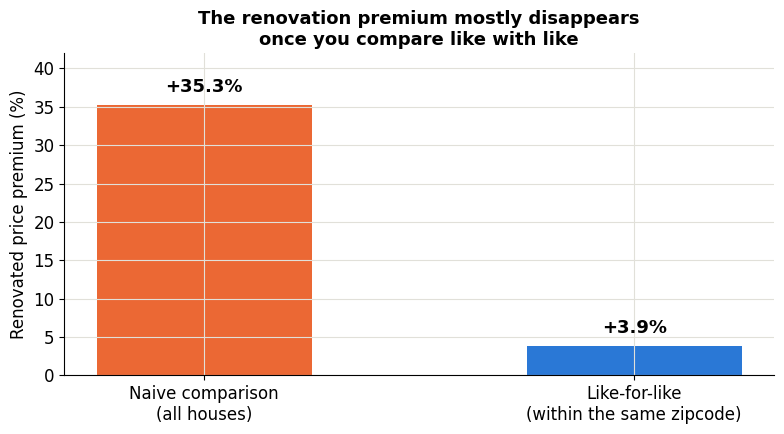

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(["Naive comparison\n(all houses)", "Like-for-like\n(within the same zipcode)"],
              [gap, within_zip["gap_pct"].median()],
              color=[ORANGE, BLUE], width=0.5)
ax.bar_label(bars, fmt="%+.1f%%", padding=6, fontsize=13, fontweight="bold")
ax.set_ylabel("Renovated price premium (%)")
ax.set_title("The renovation premium mostly disappears\nonce you compare like with like")
ax.set_ylim(0, 42)
plt.tight_layout()
plt.show()

### ❌ H2b is rejected

**The premium collapses from 35.3% to 3.9%** once we compare houses inside the same zipcode, and
it is positive in only 13 of the 21 zipcodes that qualify.

Most of that headline 35% was **location and size**, not renovation. Charles should not spend money
chasing the word "renovated".

## 8.3 Comparing all the drivers at once

The within-zipcode trick handled one confounder. But size, grade, condition, age and waterfront are
*all* tangled together. To untangle them we need a model that holds everything else constant while
it looks at each one.

That is what a **regression** does. Read the output like this: *"if I compare two houses that are
identical in every listed respect except one, how much does that one difference change the price?"*

Two technical choices, in plain terms:

- **`log_price` instead of `price`.** Section 6 showed prices are lopsided; taking the logarithm
  makes the distribution symmetric, which the model assumes. The bonus is that the results then read
  as **percentages**, which is exactly what Charles wants.
- **`C(zipcode)`** gives every zipcode its own baseline — the same like-for-like trick as above, but
  applied automatically to all 70 zipcodes at once. This is called a **fixed effect**.

In [23]:
%pip install statsmodels
import numpy as np
import statsmodels.formula.api as smf

model_data = df.copy()
model_data["log_price"] = np.log(model_data["price"])
model_data["log_sqft"]  = np.log(model_data["sqft_living"])
model_data["log_lot"]   = np.log(model_data["sqft_lot"])
model_data["zipcode"]   = model_data["zipcode"].astype(str)   # a label, not a number

model = smf.ols(
    "log_price ~ log_sqft + log_lot + grade + condition + renovated "
    "+ waterfront + house_age + bathrooms + C(zipcode)",
    data=model_data,
).fit()

print(f"Houses in the model: {int(model.nobs):,}")
print(f"R-squared: {model.rsquared:.3f}  "
      f"(the model explains {model.rsquared*100:.0f}% of the variation in price)")

Note: you may need to restart the kernel to use updated packages.
Houses in the model: 21,596
R-squared: 0.870  (the model explains 87% of the variation in price)


In [24]:
features = ["grade", "condition", "renovated", "waterfront", "bathrooms", "house_age", "log_lot"]

results = pd.DataFrame({
    "effect_on_price_%": (np.exp(model.params[features]) - 1) * 100,
    "t_statistic": model.tvalues[features],
})
# sqft is a log-log term, so "+10% area" is the meaningful way to read it
sqft_effect = (1.10 ** model.params["log_sqft"] - 1) * 100
results.loc["+10% living area"] = [sqft_effect, model.tvalues["log_sqft"]]

results = results.sort_values("effect_on_price_%", ascending=False)
display(results.round(2))

print("\nRule of thumb: |t| above about 2 means the effect is statistically reliable.")

,effect_on_price_%,t_statistic
waterfront,96.47,41.66
grade,13.56,66.21
log_lot,7.10,33.14
renovated,6.37,8.23
condition,4.45,19.37
+10% living area,4.03,69.72
bathrooms,3.93,12.96
house_age,0.06,8.19



Rule of thumb: |t| above about 2 means the effect is statistically reliable.


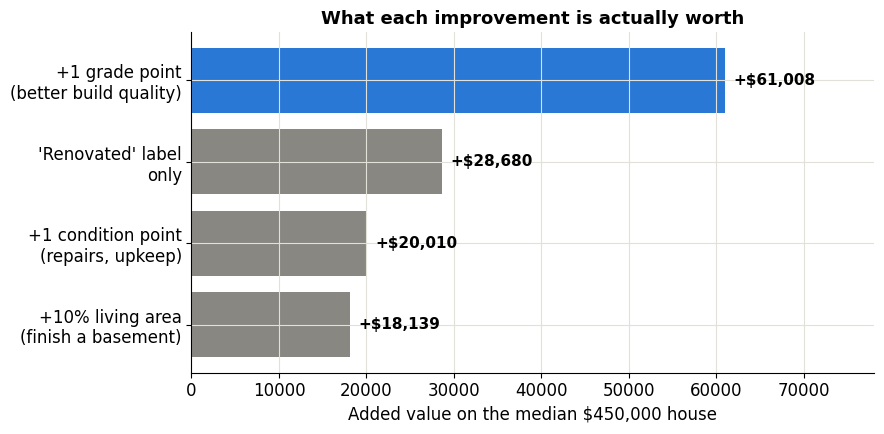

In [25]:
# Translate the percentages into money, on a typical house
median_price = df["price"].median()

levers = pd.Series({
    "+1 grade point\n(better build quality)": (np.exp(model.params["grade"]) - 1) * 100,
    "'Renovated' label\nonly":                (np.exp(model.params["renovated"]) - 1) * 100,
    "+1 condition point\n(repairs, upkeep)":  (np.exp(model.params["condition"]) - 1) * 100,
    "+10% living area\n(finish a basement)":  sqft_effect,
}).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [BLUE if "grade" in i else GREY for i in levers.index]
bars = ax.barh(levers.index, levers.values * median_price / 100, color=colors)
ax.bar_label(bars, labels=[f"+${v*median_price/100:,.0f}" for v in levers.values],
             padding=6, fontsize=11, fontweight="bold")
ax.set_xlabel(f"Added value on the median ${median_price:,.0f} house")
ax.set_title("What each improvement is actually worth")
ax.set_xlim(0, 78000)
plt.tight_layout()
plt.show()

### ✅ H2c holds — this is Insight 2

Comparing houses that are alike in every other respect:

| Lever | Effect on price | Worth on a \$450,000 house |
|---|---|---|
| **+1 grade point** | **+13.6%** | **+\$61,000** |
| "Renovated" label alone | +6.4% | +\$28,700 |
| +1 condition point | +4.4% | +\$20,000 |
| +10% living area | +4.0% | +\$18,100 |

**Build quality is worth roughly three times as much as anything else on the list**, and the market
pays very little for the "renovated" label by itself. The model explains **87%** of the variation
in price, so this is not a weak signal.

And recall from section 6 that **half the market sits at grade 6 or 7** — so there is a large supply
of houses with exactly this room to improve.

---

# 9. Q3 — When? Timing

> **H3a.** Houses sold in spring fetch more per sqft than houses sold in winter.

We compare months using **median price per sqft** rather than median price, so the answer is not
contaminated by bigger houses happening to sell in some months.

To make the size of the effect easy to read, each month is expressed as an **index**: 100 is the
year's typical level, 106 means 6% above it.

In [26]:
annual_median = df["price_per_sqft"].median()

monthly = df.groupby("sale_month").agg(
    sales=("price", "size"),
    med_ppsf=("price_per_sqft", "median"),
)
monthly["index"] = monthly["med_ppsf"] / annual_median * 100
monthly.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
display(monthly.round(1))

swing = monthly["index"].max() - monthly["index"].min()
print(f"Best month:  {monthly['index'].idxmax()} (index {monthly['index'].max():.1f})")
print(f"Worst month: {monthly['index'].idxmin()} (index {monthly['index'].min():.1f})")
print(f"Peak-to-trough swing: {swing:.1f}%")

,sales,med_ppsf,index
Jan,978,234.70,95.90
Feb,1247,237.00,96.90
Mar,1875,252.70,103.30
Apr,2229,260.00,106.30
May,2414,247.90,101.40
Jun,2177,248.50,101.60
Jul,2211,241.70,98.80
Aug,1939,246.30,100.70
Sep,1771,243.10,99.40
Oct,1876,243.90,99.70


Best month:  Apr (index 106.3)
Worst month: Dec (index 95.4)
Peak-to-trough swing: 10.9%


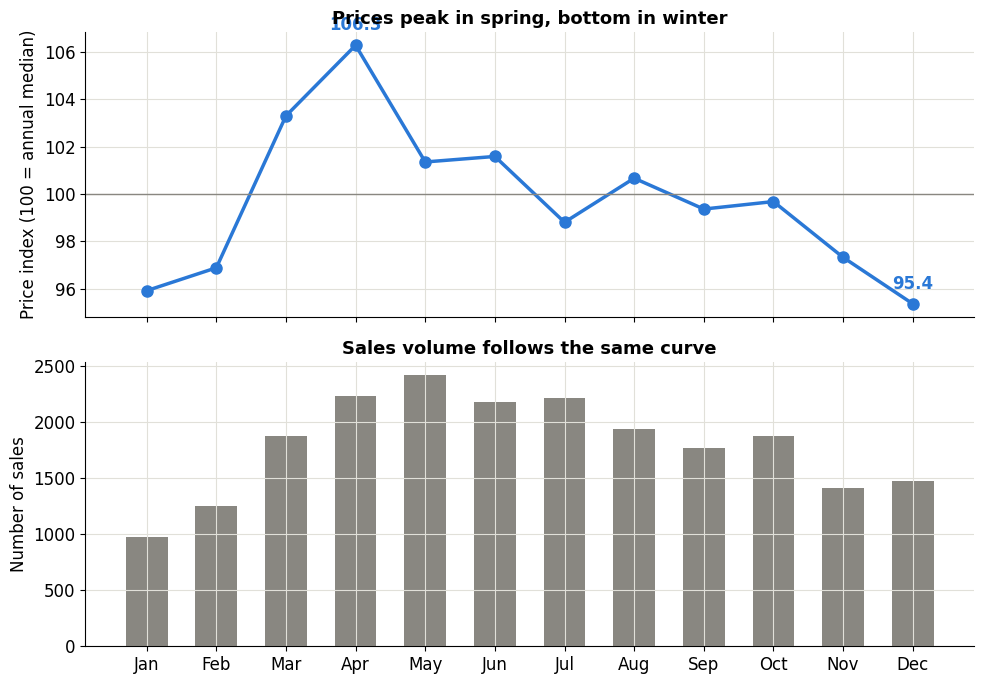

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top: the price index
axes[0].plot(monthly.index, monthly["index"], marker="o", color=BLUE,
             linewidth=2.5, markersize=8)
axes[0].axhline(100, color=GREY, linewidth=1, linestyle="-")
axes[0].set_ylabel("Price index (100 = annual median)")
axes[0].set_title("Prices peak in spring, bottom in winter")
for m in ["Apr", "Dec"]:
    axes[0].annotate(f"{monthly.loc[m, 'index']:.1f}",
                     (m, monthly.loc[m, "index"]),
                     textcoords="offset points", xytext=(0, 11),
                     ha="center", fontweight="bold", color=BLUE)

# Bottom: how many houses changed hands. SEPARATE panel, not a second y-axis on
# the same plot -- two different scales sharing one axis invents relationships
# that are not in the data.
axes[1].bar(monthly.index, monthly["sales"], color=GREY, width=0.6)
axes[1].set_ylabel("Number of sales")
axes[1].set_title("Sales volume follows the same curve")

plt.tight_layout()
plt.show()

### ✅ H3a holds — this is Insight 3

**April is the strongest month (index 106.3) and December the weakest (95.4)** — a **10.9% swing**
between the best and worst month to sell.

Volume moves with it: January sees 978 sales, May sees 2,414. Spring is when buyers show up, and
prices follow. For a \$450,000 house, selling in April rather than December is worth roughly
**\$49,000** — more than most renovations return.

⚠️ **Caveat for the slides:** this data covers one 12-month window, so this is **one** seasonal
cycle, not a proven annual pattern.

---

# 10. Q4 — The houses that sold twice 🔍

> **H4a.** Houses that sold twice in this window made a profit.
> **H4b.** The bigger the discount at purchase, the bigger the eventual gain.

Back in section 4b we noticed 21,596 sales but only 21,419 distinct houses. Some houses appear
**twice**. That means a real purchase price and a real resale price for the same property — the only
directly observed **returns** anywhere in this dataset, and exactly what a client asking about
"big returns" needs.

In [28]:
sale_counts = df["id"].value_counts()
repeat_ids = sale_counts[sale_counts >= 2].index

print(f"Houses sold more than once: {len(repeat_ids)}")
print(f"Breakdown: {sale_counts[sale_counts >= 2].value_counts().to_dict()}")
print("  (175 houses sold twice, 1 sold three times)")

Houses sold more than once: 176
Breakdown: {2: 175, 3: 1}
  (175 houses sold twice, 1 sold three times)


In [29]:
# Build one row per round trip: first sale = the purchase, last sale = the resale
flips = []
for house_id, group in df[df["id"].isin(repeat_ids)].groupby("id"):
    group = group.sort_values("date")
    buy, sell = group.iloc[0], group.iloc[-1]
    days_held = (sell["date"] - buy["date"]).days
    if days_held <= 0:
        continue
    flips.append({
        "id": house_id,
        "zipcode": buy["zipcode"],
        "sqft": buy["sqft_living"],
        "buy_date": buy["date"],   "sell_date": sell["date"],
        "buy_price": buy["price"], "sell_price": sell["price"],
        "gain": sell["price"] - buy["price"],
        "gain_pct": (sell["price"] / buy["price"] - 1) * 100,
        "days_held": days_held,
        # did any recorded feature change between the two sales?
        "grade_changed": buy["grade"] != sell["grade"],
        "cond_changed": buy["condition"] != sell["condition"],
        "sqft_changed": buy["sqft_living"] != sell["sqft_living"],
    })

flips = pd.DataFrame(flips)
print(f"Usable round trips: {len(flips)}")
flips[["zipcode", "buy_date", "sell_date", "buy_price", "sell_price",
       "gain", "gain_pct", "days_held"]].head()

Usable round trips: 176


,zipcode,buy_date,sell_date,buy_price,sell_price,gain,gain_pct,days_held
0,98002,2014-09-16,2015-04-22,"280,000.00","300,000.00","20,000.00",7.14,218
1,98055,2014-10-16,2015-04-24,"150,000.00","175,000.00","25,000.00",16.67,190
2,98023,2014-08-20,2014-10-20,"245,000.00","250,000.00","5,000.00",2.04,61
3,98106,2014-06-11,2014-12-08,"148,000.00","244,900.00","96,900.00",65.47,180
4,98003,2014-07-31,2015-01-14,"225,000.00","358,000.00","133,000.00",59.11,167


In [30]:
print(f"Median holding period: {flips['days_held'].median():.0f} days "
      f"(~{flips['days_held'].median()/30:.0f} months)")
print(f"Median gain:           ${flips['gain'].median():,.0f}  "
      f"({flips['gain_pct'].median():+.1f}%)")
print(f"Share profitable:      {(flips['gain_pct'] > 0).mean()*100:.1f}%")
print(f"Share at a loss:       {(flips['gain_pct'] < 0).mean()*100:.1f}%")

Median holding period: 178 days (~6 months)
Median gain:           $118,875  (+54.4%)
Share profitable:      94.9%
Share at a loss:       3.4%


**+54.4% in about six months, and 95% of them profitable.** That number should make you suspicious,
not excited. A whole housing market does not rise 54% in six months. Before reporting it, we have
to find out where it actually came from.

In [31]:
# How much did the MARKET move over the same window?
# Use only houses that sold once, so the flips don't contaminate their own benchmark.
single_sale = df[df["id"].isin(sale_counts[sale_counts == 1].index)]

quarterly = single_sale.groupby(
    single_sale["date"].dt.to_period("Q"))["price_per_sqft"].median()
print("Market median price per sqft, by quarter:")
print(quarterly.round(1))

market_drift = (quarterly.iloc[-1] / quarterly.iloc[0] - 1) * 100
print(f"\nMarket drift over the whole window: {market_drift:+.1f}%")
print(f"Median flip return:                 {flips['gain_pct'].median():+.1f}%")
print(f"=> a flip returned about {flips['gain_pct'].median()/market_drift:.0f}x the market's drift")

Market median price per sqft, by quarter:
date
2014Q2   247.70
2014Q3   244.40
2014Q4   239.50
2015Q1   243.50
2015Q2   258.20
Freq: Q-DEC, Name: price_per_sqft, dtype: float64

Market drift over the whole window: +4.2%
Median flip return:                 +54.4%
=> a flip returned about 13x the market's drift


**The market rose 4.2%. The flips returned 54.4%.** So the gain was *not* appreciation — almost
none of it. Something else is going on.

The next question is the one that unlocks the whole project: **were these houses bought cheap, or
sold dear?** We compare each flip's buy and sell price against the normal price per sqft in its own
zipcode.

In [32]:
# The "normal" price per sqft in each zipcode, from single-sale houses only
zip_norm = single_sale.groupby("zipcode")["price_per_sqft"].median()

flips["buy_ppsf"]    = flips["buy_price"] / flips["sqft"]
flips["sell_ppsf"]   = flips["sell_price"] / flips["sqft"]
flips["zip_norm"]    = flips["zipcode"].map(zip_norm)
flips["buy_vs_zip"]  = (flips["buy_ppsf"] / flips["zip_norm"] - 1) * 100
flips["sell_vs_zip"] = (flips["sell_ppsf"] / flips["zip_norm"] - 1) * 100

print(f"Median purchase price vs the zipcode norm: {flips['buy_vs_zip'].median():+.1f}%")
print(f"Median resale price vs the zipcode norm:   {flips['sell_vs_zip'].median():+.1f}%")

implied = ((1 + flips["sell_vs_zip"].median()/100) /
           (1 + flips["buy_vs_zip"].median()/100) - 1) * 100
print(f"\nBuying at {100 + flips['buy_vs_zip'].median():.0f}% of the norm and selling at "
      f"{100 + flips['sell_vs_zip'].median():.0f}% of it implies a gain of {implied:+.1f}%")
print(f"Observed median gain:                                              "
      f"{flips['gain_pct'].median():+.1f}%")

Median purchase price vs the zipcode norm: -23.5%
Median resale price vs the zipcode norm:   +15.4%

Buying at 77% of the norm and selling at 115% of it implies a gain of +50.8%
Observed median gain:                                              +54.4%


**There it is.** These houses were bought **23.5% below** what their neighborhood normally charges
and sold **15.4% above** it. Closing that discount alone accounts for **+50.8%** of the observed
**+54.4%**.

The return came from **the purchase price**. Now test H4b directly: does a deeper discount actually
produce a bigger gain?

In [33]:
flips["discount_band"] = pd.cut(
    flips["buy_vs_zip"],
    bins=[-100, -50, -30, -15, 0, 200],
    labels=["More than 50%\nbelow", "30-50%\nbelow", "15-30%\nbelow",
            "0-15%\nbelow", "At or above\nthe norm"],
)

by_band = flips.groupby("discount_band", observed=True).agg(
    flips=("gain_pct", "size"),
    median_gain_pct=("gain_pct", "median"),
    median_buy=("buy_price", "median"),
    median_sell=("sell_price", "median"),
)
display(by_band.round(1))

print(f"Correlation between discount at purchase and eventual gain: "
      f"{flips[['buy_vs_zip', 'gain_pct']].corr().iloc[0, 1]:.3f}")

,flips,median_gain_pct,median_buy,median_sell
discount_band,,,,
More than 50%\nbelow,8,110.00,"169,975.00","355,500.00"
30-50%\nbelow,57,64.40,"238,000.00","415,000.00"
15-30%\nbelow,42,58.10,"254,937.50","387,500.00"
0-15%\nbelow,32,42.90,"277,500.00","379,250.00"
At or above\nthe norm,37,7.10,"443,500.00","515,000.00"


Correlation between discount at purchase and eventual gain: -0.474


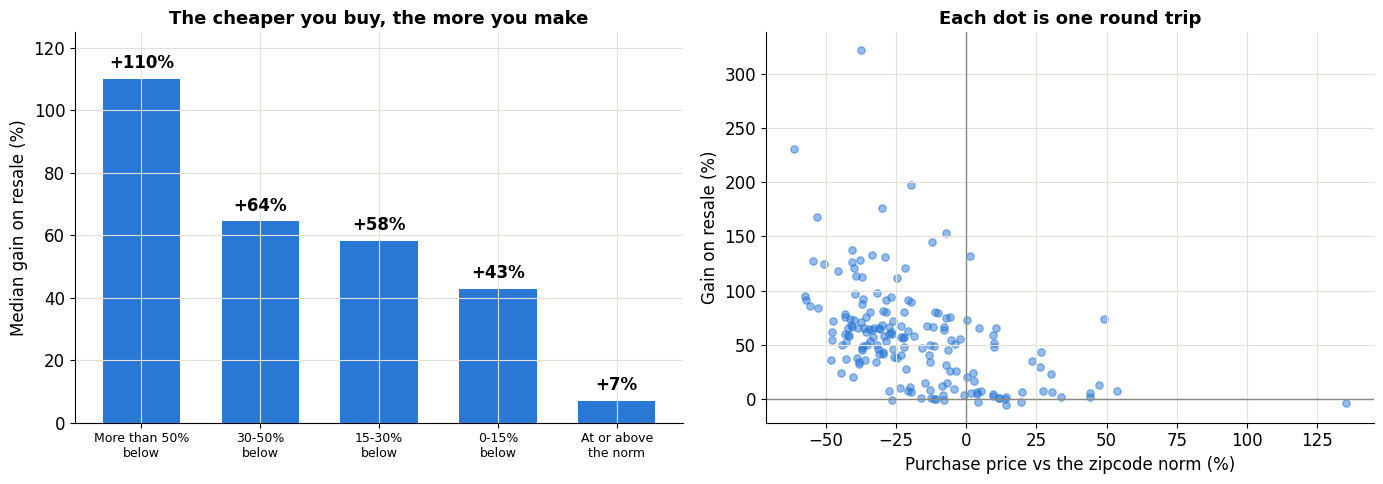

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the ladder
bars = axes[0].bar(by_band.index.astype(str), by_band["median_gain_pct"], color=BLUE, width=0.65)
axes[0].bar_label(bars, fmt="+%.0f%%", padding=5, fontweight="bold")
axes[0].set_ylabel("Median gain on resale (%)")
axes[0].set_title("The cheaper you buy, the more you make")
axes[0].tick_params(axis="x", labelsize=9)
axes[0].set_ylim(0, 125)

# Right: every individual flip
axes[1].scatter(flips["buy_vs_zip"], flips["gain_pct"], alpha=0.5, s=28, color=BLUE)
axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].axvline(0, color=GREY, linewidth=1)
axes[1].set_xlabel("Purchase price vs the zipcode norm (%)")
axes[1].set_ylabel("Gain on resale (%)")
axes[1].set_title("Each dot is one round trip")

plt.tight_layout()
plt.show()

### ✅ H4a and H4b both hold — this is Insight 4, and the headline of the project

| Bought at | Round trips | Median gain |
|---|---|---|
| More than 50% below the zipcode norm | 8 | **+110.0%** |
| 30–50% below | 57 | +64.4% |
| 15–30% below | 42 | +58.1% |
| 0–15% below | 32 | +42.9% |
| **At or above the norm** | 37 | **+7.1%** |

A perfect ladder, correlation **−0.47**. **Buy at the going rate and you make 7%. Buy 30% under and
you make 64%.**

**The profit is made on the day you buy, not the day you sell.**

## 10.1 Two checks before trusting this

Whenever a result looks this good, try to break it before someone else does.

In [35]:
# Check 1: is it just a handful of extreme bargains driving the median?
print("Median gain, all round trips:                  "
      f"{flips['gain_pct'].median():+.1f}%  (n={len(flips)})")

sub = flips[flips["buy_price"] >= 200_000]
print(f"Median gain, purchases of $200k or more:       {sub['gain_pct'].median():+.1f}%  (n={len(sub)})")

sub = flips[flips["buy_vs_zip"] > -50]
print(f"Median gain, excluding the deepest discounts:  {sub['gain_pct'].median():+.1f}%  (n={len(sub)})")

lo, hi = flips["gain_pct"].quantile([0.05, 0.95])
sub = flips[flips["gain_pct"].between(lo, hi)]
print(f"Median gain, trimming the top/bottom 5%:       {sub['gain_pct'].median():+.1f}%  (n={len(sub)})")

Median gain, all round trips:                  +54.4%  (n=176)
Median gain, purchases of $200k or more:       +44.8%  (n=123)
Median gain, excluding the deepest discounts:  +52.3%  (n=168)
Median gain, trimming the top/bottom 5%:       +54.4%  (n=158)


In [36]:
# Check 2: can we see WHAT was renovated between the two sales?
print("Round trips where a recorded feature changed between the two sales:")
print(f"  grade changed:     {flips['grade_changed'].sum()} of {len(flips)}")
print(f"  condition changed: {flips['cond_changed'].sum()} of {len(flips)}")
print(f"  sqft changed:      {flips['sqft_changed'].sum()} of {len(flips)}")

Round trips where a recorded feature changed between the two sales:
  grade changed:     0 of 176
  condition changed: 0 of 176
  sqft changed:      0 of 176


**Check 1 passes.** The finding survives every restriction — it is not a handful of outliers.

**Check 2 is a genuine limitation, and belongs in the presentation.** *Zero* features changed across
all 176 round trips. That is not because nobody renovated — it is because the `details` table holds
**one record per house, not one per sale**. The house's features are a single snapshot.

So this data **cannot** tell us what was physically done to these houses between the two sales. The
discount at purchase is what we can measure; renovation work is invisible here. Say this out loud
rather than letting someone in the audience find it.

In [37]:
# Where did the flipping actually happen?
flip_zips = flips.groupby("zipcode").agg(
    flips=("gain_pct", "size"),
    median_gain=("gain_pct", "median"),
    median_buy=("buy_price", "median"),
).query("flips >= 5").sort_values("median_gain", ascending=False)

# add liquidity from the main dataset
flip_zips["sales_per_year"] = df.groupby("zipcode").size()
display(flip_zips.round(1))

,flips,median_gain,median_buy,sales_per_year
zipcode,,,,
98106,5,117.70,"175,000.00",335
98118,9,93.90,"235,000.00",507
98146,7,75.00,"175,000.00",288
98198,5,67.90,"170,000.00",280
98023,7,64.20,"136,500.00",499
98133,9,63.40,"287,500.00",493
98055,8,63.10,"182,500.00",268
98117,5,62.80,"405,000.00",553
98115,7,60.00,"430,000.00",583


**Read the bottom row of that table.** 98006 (Bellevue) hosted 8 round trips at a median buy price
of \$952,500 — and returned **+4.5%**. It is the control case: an expensive neighborhood with no
discount available is where returns go to die.

The money was made in mid-priced, high-volume areas: **98118** (Columbia City, +93.9% across 9 round
trips), **98146** (Burien/White Center, +75.0%), **98106** (South Park, +117.7%).

---

# 11. Insights

**The dataset:** 21,596 King County home sales, 2 May 2014 – 27 May 2015, across 70 zipcodes.

### Insight 1 — Location sets the price, and the spread is enormous *(geographical)*
Median price per sqft runs from **\$145** in 98023 (Federal Way) to **\$565** in 98039 (Medina) — a
**3.9× spread**; **8×** on total price. The same house, moved across the county, changes price by a
factor of four.

### Insight 2 — Buyers pay for build quality, barely at all for the "renovated" label
Comparing like-for-like houses: **+1 grade point = +13.6% (\$61,000)**, against **+6.4%** for the
renovated flag and **+4.4%** for condition. The naive comparison says renovated houses sell for
**35.3%** more; within a single zipcode that collapses to **3.9%**. The difference was location and
size all along.

### Insight 3 — Timing is worth about 11%
April prices index at **106.3**, December at **95.4** — a **10.9% swing**, roughly **\$49,000** on a
median house. Volume follows the same curve (978 sales in January, 2,414 in May).

### Insight 4 — The return is made at purchase, not at sale *(the headline)*
The 176 houses that sold twice returned a median **+54.4% in six months** while the market moved
**+4.2%**. They were bought **23.5% below** the zipcode norm and sold **15.4% above** it — which
explains **+50.8%** of the **+54.4%**. Buy at the going rate and the median gain is **+7.1%**;
buy 30% under and it is **+64.4%**.

---

# 12. Recommendations for Charles Christensen

### 1. Hunt discounted stock in mid-priced, high-volume zipcodes
The return is made at purchase, which points **away** from prestige areas. Target **98118**
(Columbia City) — 507 sales a year, one of the widest internal price spreads in the county, and nine
observed round trips at a median **+93.9%**. **98146** (Burien) is the highest-upside alternative.
Avoid the 98006 pattern: expensive, liquid, and nothing to buy below market.

*Set a rule:* **do not buy above the zipcode's median price per sqft.** In this data that single
rule separates a +7% outcome from a +64% one.

### 2. Renovate for grade and square footage — never for the label
On a \$450,000 house: one **grade** point is worth **+\$61,000**; **+10% living area** (finishing a
basement) **+\$18,100**; one **condition** point **+\$20,000**. The "renovated" sticker on its own
adds almost nothing once location is accounted for. Half the market sits at grade 6–7, so there is
plenty of stock with room to move.

*Priority order:* buy the discount → fix condition → lift grade → add square footage.

### 3. Buy in winter, sell in spring
Close purchases in **December or January** (index 95.4 and 95.9, and January is the thinnest month
of the year at 978 sales, so least competition). Close sales in **March or April** (103.3, 106.3).
That captures most of the 10.9% swing on **both** sides — about **\$49,000** on a median house,
before any building work. Working back from an April sale, any work must be finished by **February**,
which fits inside the observed median round trip of 178 days.

---

## ⚠️ Caveats — say these in the presentation before anyone asks

1. **The 176 repeat sales are self-selected.** They are houses somebody chose to trade twice, so
   they over-represent successful flips. +54.4% is what *this kind of transaction* returned, not
   what any house would return.
2. **Some purchases may not be arm's-length.** Nearly a third were under \$200,000 in a market with
   a \$450,000 median. Foreclosures, auctions and family transfers all look like this, and the data
   has no transaction-type column to check.
3. **All returns are gross.** No renovation cost, agent fees, closing costs or carrying costs. Net
   returns will be materially lower.
4. **House features are one snapshot per house**, so this data cannot show what was renovated
   between two sales (section 10.1).
5. **One 12-month window.** The seasonality is a single cycle, not a proven annual pattern. May
   appears in both 2014 and 2015, and May 2015 is partial.
6. **No days-on-market and no asking price**, so "timing" means the date of sale, not of listing.
7. `yr_renovated` is missing for 3,848 rows and is only a yes/no flag when present — it says nothing
   about the scope or cost of the work.

---

# 13. Presentation charts (Plotly)

Everything above was built for **thinking**: fast, plain, disposable. This section is built for
**showing** — seven charts for the slide deck, exported as high-resolution PNGs you can drop
straight into PowerPoint.

### The rules these charts follow

1. **One idea per chart.** If a chart needs two sentences to explain, it is two charts.
2. **Colour carries meaning, never decoration.** One blue for everything; orange *only* to mark the
   thing the slide is about. A reader should learn "orange = the point" once and have it hold.
3. **Never two y-axes on one plot.** Two different scales sharing one chart invents relationships
   that are not in the data. Use two stacked panels instead (chart 7).
4. **Label the values that matter, not every point.** A number on every bar is noise.
5. **Recessive chrome.** Hairline gridlines, no box around the plot, no heavy borders.

The palette is colourblind-safe: blue `#2a78d6` and orange `#eb6834` stay distinguishable under
deuteranopia and protanopia, the two most common forms of colour vision deficiency. About 1 in 12
men has one — in a room of clients, assume someone does.

> **Before running this section** you need `kaleido` installed (`uv add kaleido`), and it needs a
> copy of Chrome to render images with. If you see *"Kaleido requires Google Chrome"*, run
> `uv run plotly_get_chrome` once in your terminal and re-run the cell.

In [38]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from pathlib import Path

OUT = Path("presentation_charts")
OUT.mkdir(exist_ok=True)

# ---- Design tokens -----------------------------------------------------
SURFACE   = "#fcfcfb"   # chart background
INK       = "#0b0b0b"   # titles
INK_2     = "#52514e"   # subtitles, axis titles
MUTED     = "#898781"   # tick labels, de-emphasised bars
GRID      = "#e1e0d9"   # hairline gridlines
BASELINE  = "#c3c2b7"   # axis line
SERIES_1  = "#2a78d6"   # blue   - the default for everything
SERIES_2  = "#eb6834"   # orange - the accent, used sparingly
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

FONT = "system-ui, -apple-system, Segoe UI, Helvetica, Arial, sans-serif"

# A reusable template so every chart looks like it came from the same deck
pio.templates["deck"] = go.layout.Template(
    layout=dict(
        font=dict(family=FONT, size=15, color=INK_2),
        paper_bgcolor=SURFACE,
        plot_bgcolor=SURFACE,
        title=dict(font=dict(size=24, color=INK), x=0.012, xanchor="left",
                   subtitle=dict(font=dict(size=16, color=INK_2))),
        margin=dict(l=80, r=50, t=125, b=70),
        xaxis=dict(showgrid=False, linecolor=BASELINE, linewidth=1, ticks="outside",
                   tickcolor=BASELINE, ticklen=5, tickfont=dict(color=MUTED, size=14),
                   title=dict(font=dict(size=15, color=INK_2))),
        yaxis=dict(gridcolor=GRID, gridwidth=1, zeroline=False, showline=False,
                   tickfont=dict(color=MUTED, size=14),
                   title=dict(font=dict(size=15, color=INK_2))),
        colorway=[SERIES_1, SERIES_2],
        legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="right", x=1,
                    bgcolor="rgba(0,0,0,0)", font=dict(size=14)),
        hoverlabel=dict(font=dict(family=FONT, size=14), bordercolor=BASELINE),
    )
)
pio.templates.default = "deck"

W, H, SCALE = 1400, 800, 2          # 2800 x 1600 px PNGs - sharp on any projector

def save(fig, name, w=None, h=None):
    # Write a PNG for PowerPoint, and return the figure so it also shows here
    fig.write_image(OUT / f"{name}.png", width=w or W, height=h or H, scale=SCALE)
    print(f"saved -> {OUT / (name + '.png')}")
    return fig

def subtitle(fig, text):
    # The takeaway sentence, placed under the title by plotly itself
    fig.update_layout(title_subtitle_text=text)
    return fig

print("Chart styling ready.")

Chart styling ready.


## Chart 1 — Where the money is (the geographical insight)

Latitude and longitude plotted against each other draw King County itself. Colour is a **sequential**
ramp — one hue, light to dark — because price per sqft is a *magnitude*. A rainbow scale here would
be unreadable: nobody knows whether green is more than purple.

In [4]:
df = pd.read_csv("data/eda.csv")


plot_df = df.sample(min(len(df), 12000), random_state=42)   # keeps the file light

fig = go.Figure(go.Scattergl(
    x=plot_df["long"], y=plot_df["lat"], mode="markers",
    marker=dict(
        size=4.5, opacity=0.75,
        color=plot_df["price_per_sqft"],
        colorscale=[[i/(len(BLUE_RAMP)-1), c] for i, c in enumerate(BLUE_RAMP)],
        cmin=df["price_per_sqft"].quantile(0.02),
        cmax=df["price_per_sqft"].quantile(0.98),
        colorbar=dict(title=dict(text="$ / sqft", side="top"), thickness=14,
                      len=0.55, outlinewidth=0, tickfont=dict(color=MUTED)),
    ),
    hovertemplate="$%{marker.color:.0f} per sqft<extra></extra>",
))

fig.update_layout(
    title="Location sets the price",
    xaxis=dict(title="Longitude", showgrid=False, range=[-122.55, -121.92]),
    yaxis=dict(title="Latitude", showgrid=False, range=[47.15, 47.80],
               scaleanchor="x", scaleratio=1.45),   # keeps the map geographically true
)
subtitle(fig, "Median price per square foot ranges from $145 to $565 across King County — a 3.9× spread")

# Labels are nudged apart by hand so they do not overlap each other
for label, lon, lat in [("Seattle", -122.335, 47.615), ("Bellevue", -122.175, 47.612),
                        ("Federal Way", -122.325, 47.312)]:
    fig.add_annotation(x=lon, y=lat, text=label, showarrow=False,
                       font=dict(size=14, color=INK), bgcolor="rgba(252,252,251,0.82)",
                       borderpad=3)

# A taller frame than the other charts, so the county keeps its real shape.
# On the slide, place this one on the left with your takeaway text beside it.
save(fig, "01_geography_map", w=1150, h=1000)
fig.show()

KeyError: 'price_per_sqft'

## Chart 2 — The size of the gap

The map shows the *pattern*; this shows the *magnitude*. The eight most expensive zipcodes in blue,
the eight cheapest in grey — greying the comparison group keeps the eye on the point being made.

In [5]:
top8 = zip_stats.head(8)
bot8 = zip_stats.tail(8).sort_values("med_ppsf")
combo = pd.concat([bot8, top8])

fig = go.Figure(go.Bar(
    y=[str(z) for z in combo.index], x=combo["med_ppsf"], orientation="h",
    marker=dict(color=[MUTED]*8 + [SERIES_1]*8, cornerradius=4),
    text=[f"${v:,.0f}" for v in combo["med_ppsf"]],
    textposition="outside", textfont=dict(size=14, color=INK_2),
    hovertemplate="Zipcode %{y}<br>$%{x:.0f} per sqft<extra></extra>",
))
fig.update_layout(
    title="The most expensive zipcode costs 3.9× the cheapest",
    xaxis=dict(title="Median price per square foot", showgrid=True, gridcolor=GRID,
               range=[0, 690], tickprefix="$"),
    # type="category" is essential: zipcodes LOOK like numbers, and without this
    # plotly plots them on a numeric axis and the chart falls apart
    yaxis=dict(title="Zipcode", showgrid=False, tickfont=dict(size=14),
               type="category"),
    showlegend=False,
)
subtitle(fig, "The eight cheapest zipcodes (grey) against the eight most expensive (blue)")
save(fig, "02_zipcode_spread")
fig.show()

NameError: name 'zip_stats' is not defined

## Chart 3 — The headline: the return is made at purchase

The one chart to build the presentation around. Orange marks the two ends of the story — buy at the
going rate, make 7%; buy 30% under, make 64%.

In [6]:
bands = by_band.reset_index()
bands["label"] = bands["discount_band"].astype(str).str.replace("\n", " ")
colors = [SERIES_1] * len(bands)
colors[0] = SERIES_2                     # deepest discount
colors[-1] = SERIES_2                    # no discount

fig = go.Figure(go.Bar(
    x=bands["label"], y=bands["median_gain_pct"],
    marker=dict(color=colors, cornerradius=4),
    text=[f"+{v:.0f}%" for v in bands["median_gain_pct"]],
    textposition="outside", textfont=dict(size=17, color=INK),
    customdata=bands["flips"],
    hovertemplate="%{x}<br>Median gain +%{y:.1f}%<br>%{customdata} round trips<extra></extra>",
))
fig.update_layout(
    title="The profit is made on the day you buy",
    xaxis=dict(title="Purchase price, relative to the zipcode's normal price per sqft"),
    yaxis=dict(title="Median gain on resale", ticksuffix="%", range=[0, 130]),
    showlegend=False,
)
subtitle(fig, "176 houses that sold twice within the year · median holding period 6 months")
fig.add_annotation(x=4, y=30, showarrow=False,
                   text="Pay the going rate<br>and there is no margin",
                   font=dict(size=15, color=SERIES_2), align="center")
save(fig, "03_discount_ladder")
fig.show()

NameError: name 'by_band' is not defined

## Chart 4 — It was not the market

The obvious objection to chart 3 is *"prices just went up."* They did not. Two bars, direct labels,
no axis clutter needed.

In [7]:
fig = go.Figure(go.Bar(
    x=["The market<br>(all single-sale houses)", "The 176 houses<br>that sold twice"],
    y=[market_drift, flips["gain_pct"].median()],
    marker=dict(color=[MUTED, SERIES_1], cornerradius=4), width=[0.42, 0.42],
    text=[f"+{market_drift:.1f}%", f"+{flips['gain_pct'].median():.1f}%"],
    textposition="outside", textfont=dict(size=30, color=INK),
    hovertemplate="%{x}<br>%{y:.1f}%<extra></extra>",
))
fig.update_layout(
    title="A flip returned 13× what the market did",
    xaxis=dict(title=""),
    yaxis=dict(title="Change over the 12-month window", ticksuffix="%", range=[0, 68]),
    showlegend=False, margin=dict(l=80, r=50, t=125, b=80),
)
subtitle(fig, "May 2014 – May 2015 · so the gain came from buying below market, not from appreciation")
save(fig, "04_flip_vs_market")
fig.show()

NameError: name 'market_drift' is not defined

## Chart 5 — The renovation trap

The methodological point, and the most persuasive thing in the deck: the same question, asked two
ways, gives two very different answers. Orange is the wrong answer, blue the right one.

In [8]:
fig = go.Figure(go.Bar(
    x=["Comparing all houses<br><i>(what it looks like)</i>",
       "Comparing houses in the<br>same zipcode <i>(what is true)</i>"],
    y=[gap, within_zip["gap_pct"].median()],
    marker=dict(color=[SERIES_2, SERIES_1], cornerradius=4), width=[0.42, 0.42],
    text=[f"+{gap:.1f}%", f"+{within_zip['gap_pct'].median():.1f}%"],
    textposition="outside", textfont=dict(size=30, color=INK),
    hovertemplate="%{x}<br>%{y:.1f}%<extra></extra>",
))
fig.update_layout(
    title="Renovated houses are not worth 35% more",
    xaxis=dict(title=""),
    yaxis=dict(title="Price premium for a renovated house", ticksuffix="%", range=[0, 44]),
    showlegend=False, margin=dict(l=80, r=50, t=125, b=80),
)
subtitle(fig, "Renovated houses are also bigger and in better areas — that, not the renovation, was the gap")
save(fig, "05_renovation_trap")
fig.show()

NameError: name 'gap' is not defined

## Chart 6 — What each improvement is actually worth

Turns percentages into money, which is the language the client thinks in. Sorted largest to
smallest so the ranking is the message; only the winner is coloured.

In [9]:
lever_data = pd.DataFrame({
    "lever": ["Raise build quality<br>by one grade point",
              "The 'renovated' label<br>on its own",
              "Raise condition<br>by one point",
              "Add 10% living area<br>(finish a basement)"],
    "pct": [(np.exp(model.params["grade"]) - 1) * 100,
            (np.exp(model.params["renovated"]) - 1) * 100,
            (np.exp(model.params["condition"]) - 1) * 100,
            sqft_effect],
}).sort_values("pct")
lever_data["dollars"] = lever_data["pct"] * median_price / 100

fig = go.Figure(go.Bar(
    y=lever_data["lever"], x=lever_data["dollars"], orientation="h",
    marker=dict(color=[MUTED, MUTED, MUTED, SERIES_1], cornerradius=4), width=0.62,
    text=[f"+${v:,.0f}" for v in lever_data["dollars"]],
    textposition="outside", textfont=dict(size=19, color=INK),
    customdata=lever_data["pct"],
    hovertemplate="%{y}<br>+$%{x:,.0f}  (+%{customdata:.1f}%)<extra></extra>",
))
fig.update_layout(
    title="Build quality is worth three times anything else",
    xaxis=dict(title=f"Added value on the median ${median_price:,.0f} house",
               showgrid=True, gridcolor=GRID, tickprefix="$", range=[0, 82000]),
    yaxis=dict(title="", showgrid=False, tickfont=dict(size=14)),
    showlegend=False, margin=dict(l=340, r=60, t=125, b=70),
)
subtitle(fig, "Comparing houses that are alike in size, age, location and everything else recorded")
save(fig, "06_value_levers")
fig.show()

NameError: name 'model' is not defined

## Chart 7 — Timing

Price and volume are different quantities on different scales, so they get **two stacked panels
sharing one x-axis** — never two y-axes on one plot. The line panel carries the message; the bar
panel supports it by showing that buyers, not just prices, arrive in spring.

In [10]:
from plotly.subplots import make_subplots

months = list(monthly.index)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.13,
                    row_heights=[0.62, 0.38],
                    subplot_titles=("Price per square foot, indexed to the yearly median",
                                    "Number of sales"))

fig.add_trace(go.Scatter(
    x=months, y=monthly["index"], mode="lines+markers",
    line=dict(color=SERIES_1, width=3),
    marker=dict(size=10, color=SERIES_1, line=dict(width=2, color=SURFACE)),
    hovertemplate="%{x}: index %{y:.1f}<extra></extra>", showlegend=False,
), row=1, col=1)

fig.add_hline(y=100, line=dict(color=BASELINE, width=1), row=1, col=1)

for m, colour, shift in [("Apr", SERIES_2, 26), ("Dec", SERIES_2, -30)]:
    fig.add_trace(go.Scatter(
        x=[m], y=[monthly.loc[m, "index"]], mode="markers",
        marker=dict(size=14, color=colour, line=dict(width=2, color=SURFACE)),
        hoverinfo="skip", showlegend=False), row=1, col=1)
    fig.add_annotation(x=m, y=monthly.loc[m, "index"], yshift=shift,
                       text=f"<b>{monthly.loc[m, 'index']:.1f}</b>", showarrow=False,
                       font=dict(size=17, color=colour), row=1, col=1)

fig.add_trace(go.Bar(
    x=months, y=monthly["sales"],
    marker=dict(color=MUTED, cornerradius=3),
    hovertemplate="%{x}: %{y:,} sales<extra></extra>", showlegend=False,
), row=2, col=1)

fig.update_layout(
    title="Sell in April, not December",
    margin=dict(l=80, r=50, t=140, b=70),
)
fig.update_xaxes(ticks="", showticklabels=False, row=1, col=1)
fig.update_yaxes(title_text="Index (100 = annual median)", gridcolor=GRID, row=1, col=1)
fig.update_yaxes(title_text="Sales", gridcolor=GRID, row=2, col=1)
fig.update_xaxes(showline=True, linecolor=BASELINE, row=2, col=1)
for ann in fig.layout.annotations[:2]:      # the two subplot titles
    ann.font = dict(size=15, color=INK_2)
    ann.x, ann.xanchor = 0, "left"

subtitle(fig, "A 10.9% swing between the best and worst month — about $49,000 on a median house")
save(fig, "07_seasonality")
fig.show()

NameError: name 'monthly' is not defined